In [113]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df = pd.read_csv('heart_disease_uci.csv')


In [114]:
df.describe()



,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


In [115]:
df

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
915,916,54,Female,VA Long Beach,asymptomatic,127.0,333.0,True,st-t abnormality,154.0,False,0.0,NaN,NaN,NaN,1
916,917,62,Male,VA Long Beach,typical angina,NaN,139.0,False,st-t abnormality,NaN,NaN,NaN,NaN,NaN,NaN,0
917,918,55,Male,VA Long Beach,asymptomatic,122.0,223.0,True,st-t abnormality,100.0,False,0.0,NaN,NaN,fixed defect,2
918,919,58,Male,VA Long Beach,asymptomatic,NaN,385.0,True,lv hypertrophy,NaN,NaN,NaN,NaN,NaN,NaN,0


In [116]:
df['dataset'].groupby(df['dataset']).count()

dataset
Cleveland        304
Hungary          293
Switzerland      123
VA Long Beach    200
Name: dataset, dtype: int64

In [117]:
df['num'].groupby(df['num']).count()

num
0    411
1    265
2    109
3    107
4     28
Name: num, dtype: int64

In [118]:
df.shape

(920, 16)

In [119]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    str    
 3   dataset   920 non-null    str    
 4   cp        920 non-null    str    
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    str    
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    str    
 13  ca        309 non-null    float64
 14  thal      434 non-null    str    
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(2), str(6)
memory usage: 115.1+ KB


In [120]:
df.isnull().sum()

id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64

In [121]:
print("Chol missing — target distribution:")
print(df[df['chol'].isna()]['num'].value_counts(normalize=True))

print("\nChol present — target distribution:")
print(df[df['chol'].notna()]['num'].value_counts(normalize=True))

Chol missing — target distribution:
num
0    0.633333
1    0.233333
2    0.066667
4    0.033333
3    0.033333
Name: proportion, dtype: float64

Chol present — target distribution:
num
0    0.440449
1    0.289888
2    0.120225
3    0.119101
4    0.030337
Name: proportion, dtype: float64


In [122]:
df['target'] = (df['num'] > 0).astype(int)
df = df.drop('num', axis=1)

In [123]:
#fix boolean values

#bool values are not needed for modeling, so we can convert them to integers
# df['fbs'] = df['fbs'].astype(int)
# df['exang'] = df['exang'].astype(int)
df['fbs'] = df['fbs'].map({True: 1, False: 0})
df['exang'] = df['exang'].map({True: 1, False: 0})

In [124]:
df = df.drop(columns=['id', 'dataset', 'ca', 'thal'])
print(df.shape)
print(df['target'].value_counts(normalize=True))

(920, 12)
target
1    0.553261
0    0.446739
Name: proportion, dtype: float64


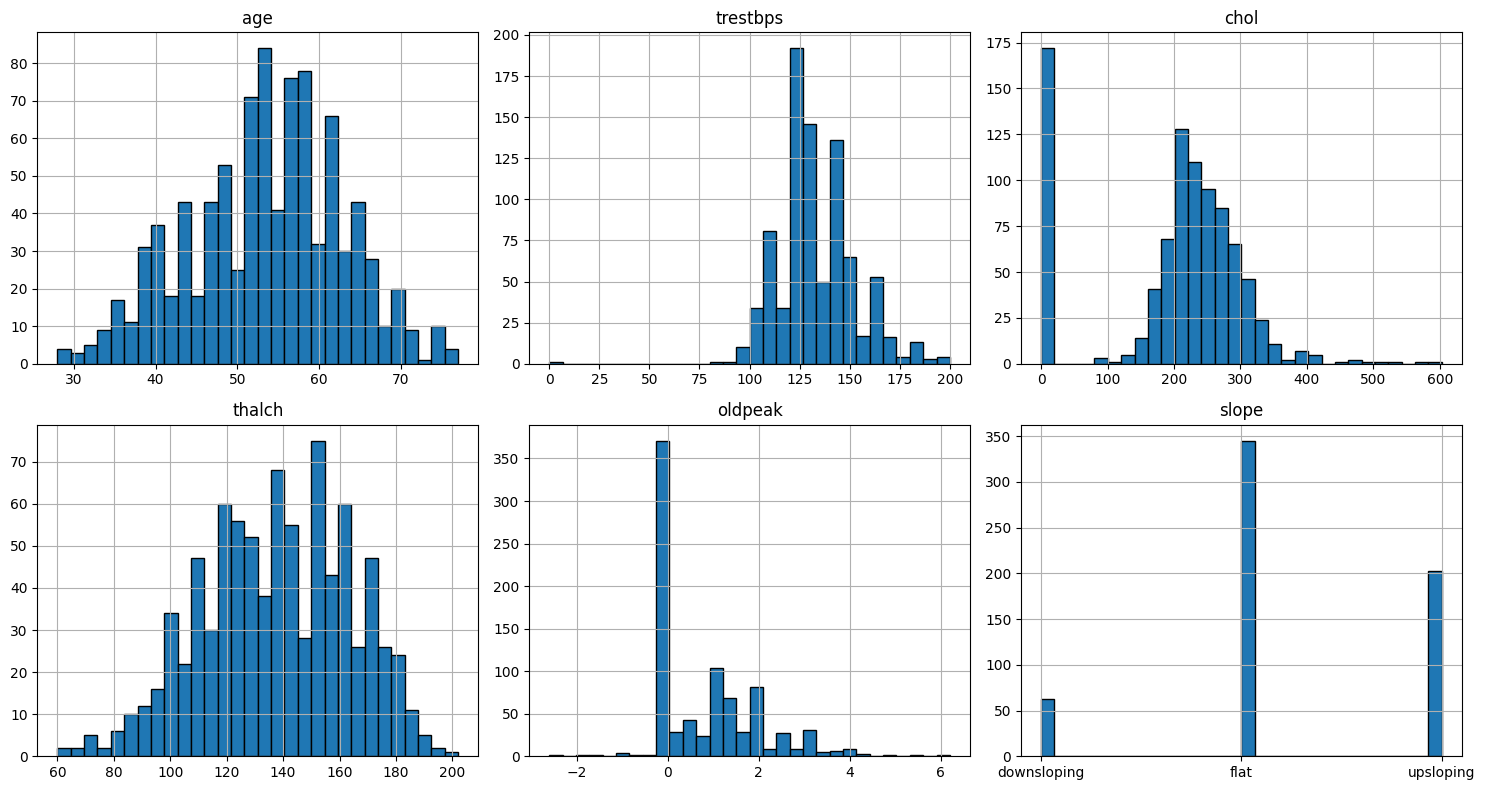

In [125]:
import matplotlib.pyplot as plt
import seaborn as sns

# Continuous columns
cont_cols = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'slope']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flatten(), cont_cols):
    df[col].hist(bins=30, ax=ax, edgecolor='black')
    ax.set_title(col)
plt.tight_layout()
plt.show()

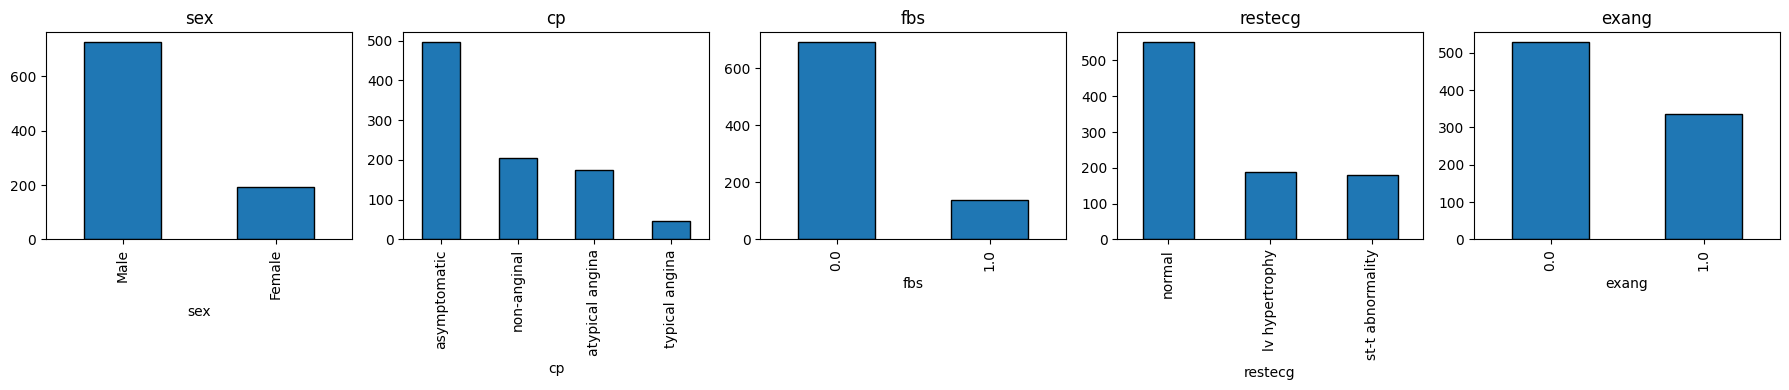

In [126]:
# Categorical + binary columns
cat_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang']

fig, axes = plt.subplots(1, 5, figsize=(18, 4))
for ax, col in zip(axes.flatten(), cat_cols):
    df[col].value_counts().plot(kind='bar', ax=ax, edgecolor='black')
    ax.set_title(col)
plt.tight_layout()
plt.show()

In [127]:
print((df['chol'] == 0).sum())
print((df['trestbps'] == 0).sum())

172
1


In [128]:
df['chol'] = df['chol'].replace(0, np.nan)
df['trestbps'] = df['trestbps'].replace(0, np.nan)

In [129]:
df.isnull().sum()

age           0
sex           0
cp            0
trestbps     60
chol        202
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
target        0
dtype: int64

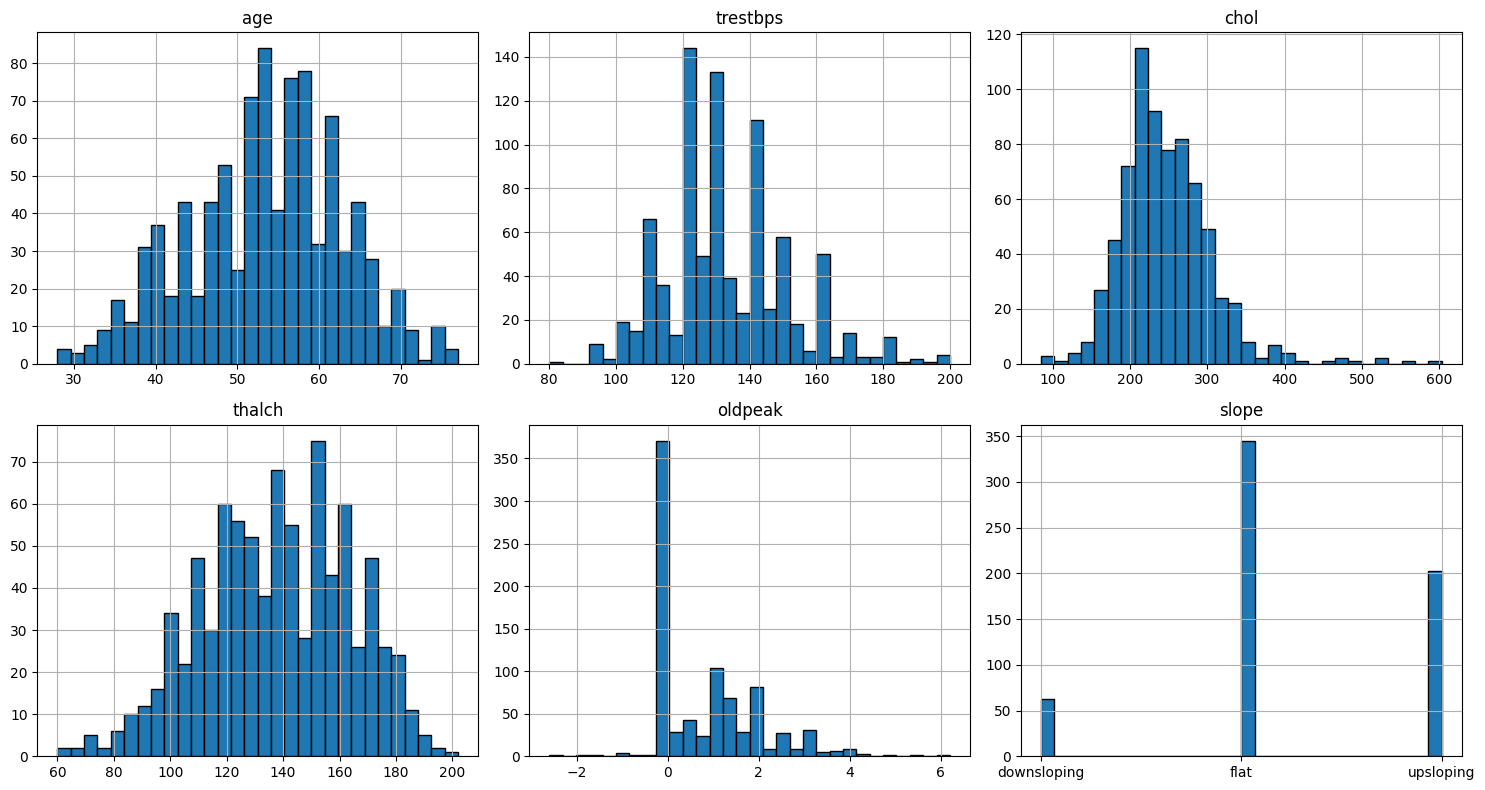

In [130]:
import matplotlib.pyplot as plt
import seaborn as sns

# Continuous columns
cont_cols = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'slope']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flatten(), cont_cols):
    df[col].hist(bins=30, ax=ax, edgecolor='black')
    ax.set_title(col)
plt.tight_layout()
plt.show()


In [131]:
print((df['chol'] == 0).sum())
print((df['trestbps'] == 0).sum())
print(df['fbs'].dtype)
print(df['exang'].dtype)

0
0
float64
float64


In [132]:
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,target
0,63,Male,typical angina,145.0,233.0,1.0,lv hypertrophy,150.0,0.0,2.3,downsloping,0
1,67,Male,asymptomatic,160.0,286.0,0.0,lv hypertrophy,108.0,1.0,1.5,flat,1
2,67,Male,asymptomatic,120.0,229.0,0.0,lv hypertrophy,129.0,1.0,2.6,flat,1
3,37,Male,non-anginal,130.0,250.0,0.0,normal,187.0,0.0,3.5,downsloping,0
4,41,Female,atypical angina,130.0,204.0,0.0,lv hypertrophy,172.0,0.0,1.4,upsloping,0
...,...,...,...,...,...,...,...,...,...,...,...,...
915,54,Female,asymptomatic,127.0,333.0,1.0,st-t abnormality,154.0,0.0,0.0,NaN,1
916,62,Male,typical angina,NaN,139.0,0.0,st-t abnormality,NaN,NaN,NaN,NaN,0
917,55,Male,asymptomatic,122.0,223.0,1.0,st-t abnormality,100.0,0.0,0.0,NaN,1
918,58,Male,asymptomatic,NaN,385.0,1.0,lv hypertrophy,NaN,NaN,NaN,NaN,0


In [133]:
print((df['thalch'] == 0).sum())

0


In [134]:
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,target
0,63,Male,typical angina,145.0,233.0,1.0,lv hypertrophy,150.0,0.0,2.3,downsloping,0
1,67,Male,asymptomatic,160.0,286.0,0.0,lv hypertrophy,108.0,1.0,1.5,flat,1
2,67,Male,asymptomatic,120.0,229.0,0.0,lv hypertrophy,129.0,1.0,2.6,flat,1
3,37,Male,non-anginal,130.0,250.0,0.0,normal,187.0,0.0,3.5,downsloping,0
4,41,Female,atypical angina,130.0,204.0,0.0,lv hypertrophy,172.0,0.0,1.4,upsloping,0
...,...,...,...,...,...,...,...,...,...,...,...,...
915,54,Female,asymptomatic,127.0,333.0,1.0,st-t abnormality,154.0,0.0,0.0,NaN,1
916,62,Male,typical angina,NaN,139.0,0.0,st-t abnormality,NaN,NaN,NaN,NaN,0
917,55,Male,asymptomatic,122.0,223.0,1.0,st-t abnormality,100.0,0.0,0.0,NaN,1
918,58,Male,asymptomatic,NaN,385.0,1.0,lv hypertrophy,NaN,NaN,NaN,NaN,0


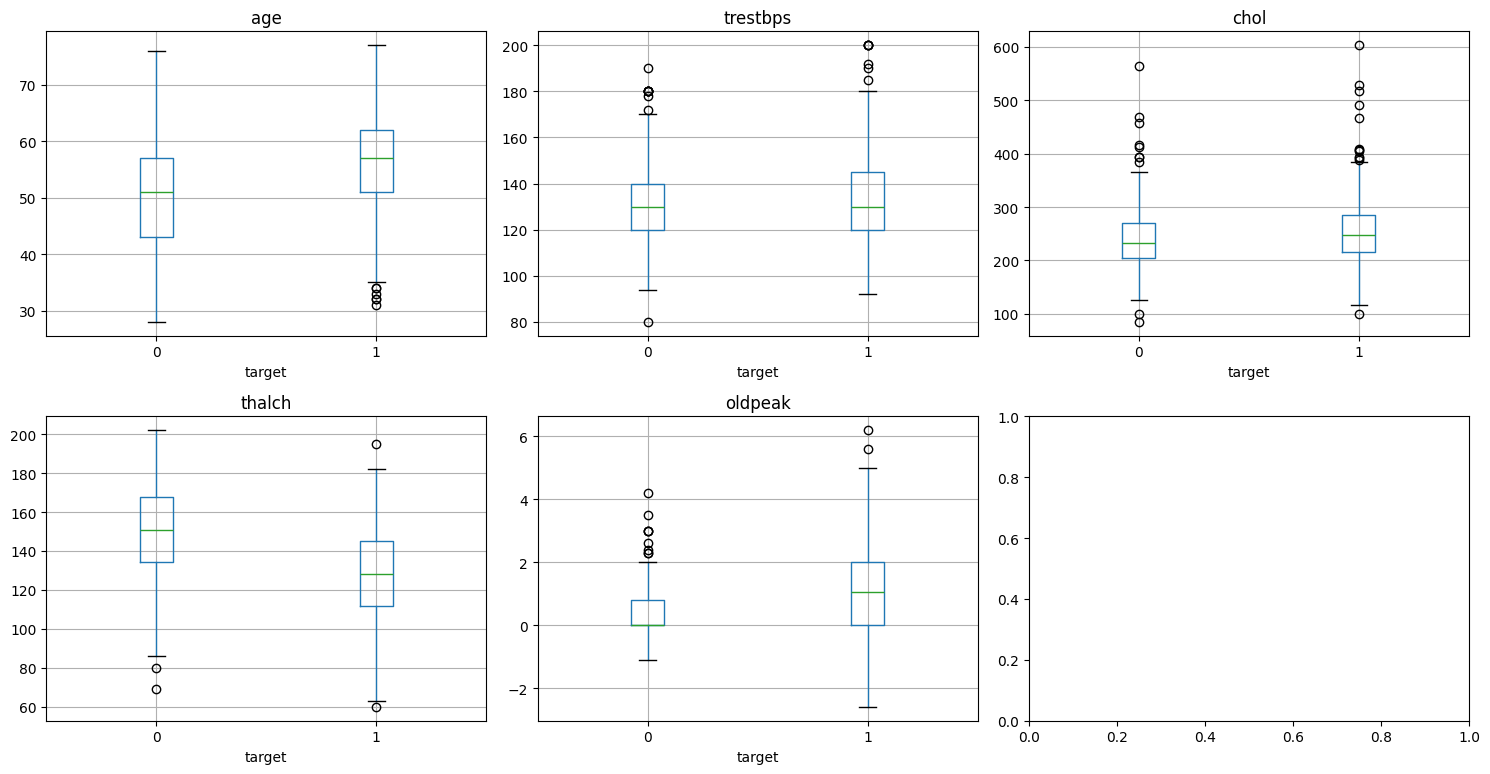

In [135]:
#bivariate analysis
# Continuous features vs target
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flatten(), ['age', 'trestbps', 'chol', 'thalch', 'oldpeak']):
    df.boxplot(column=col, by='target', ax=ax)
    ax.set_title(col)
plt.suptitle('')
plt.tight_layout()
plt.show()

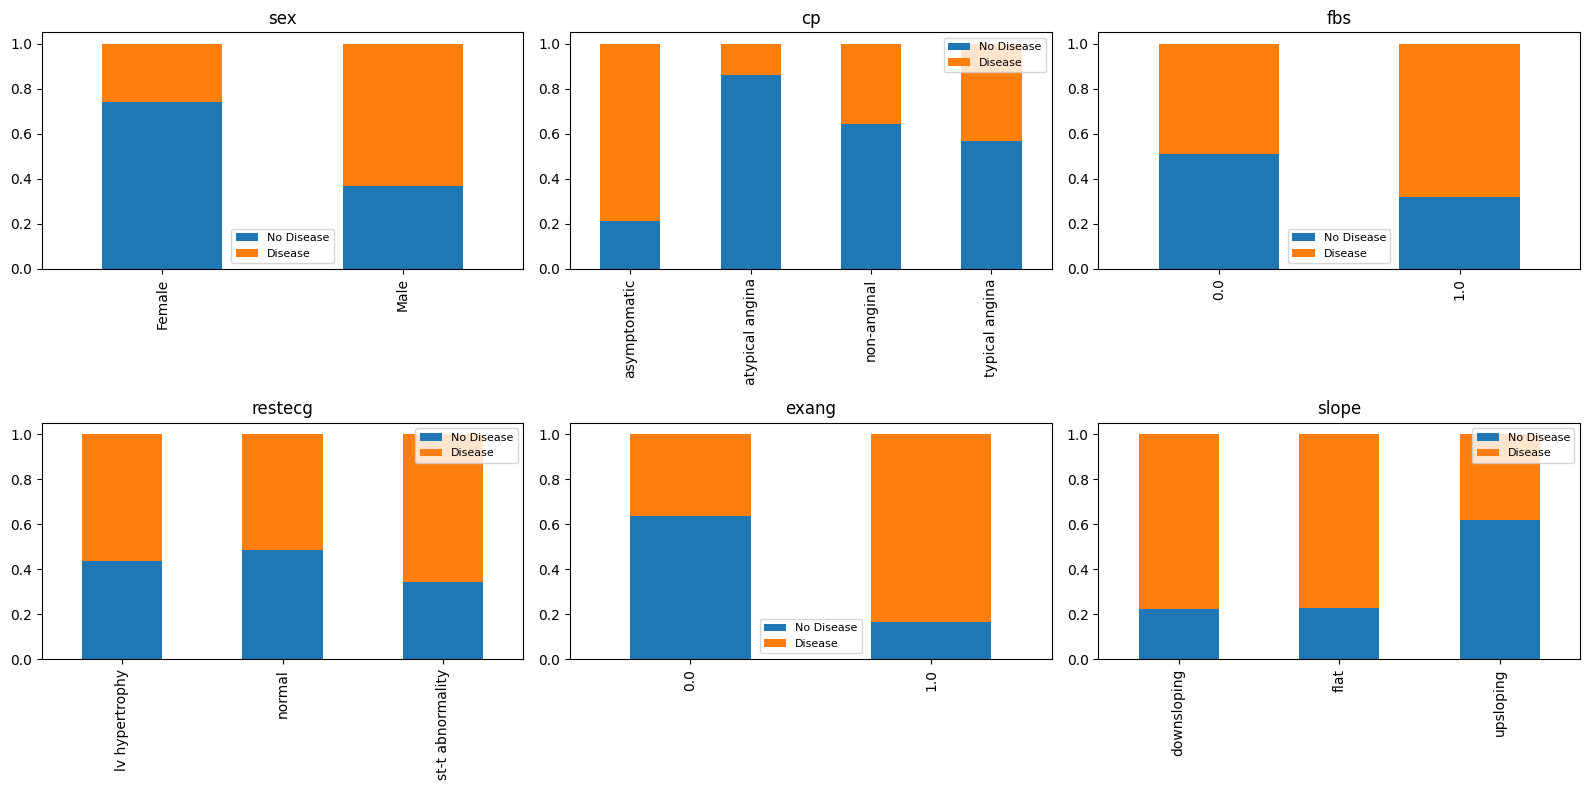

In [136]:
cat_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.flatten(), cat_cols):
    ct = pd.crosstab(df[col], df['target'], normalize='index')
    ct.plot(kind='bar', ax=ax, stacked=True)
    ax.set_title(col)
    ax.set_xlabel('')
    ax.legend(['No Disease', 'Disease'], fontsize=8)
plt.tight_layout()
plt.show()

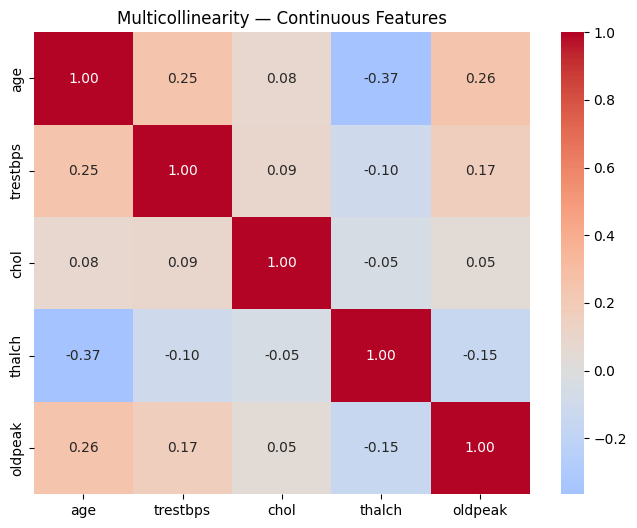

In [137]:
#multicollinearity
corr = df[['age','trestbps','chol','thalch','oldpeak']].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Multicollinearity — Continuous Features')
plt.show()

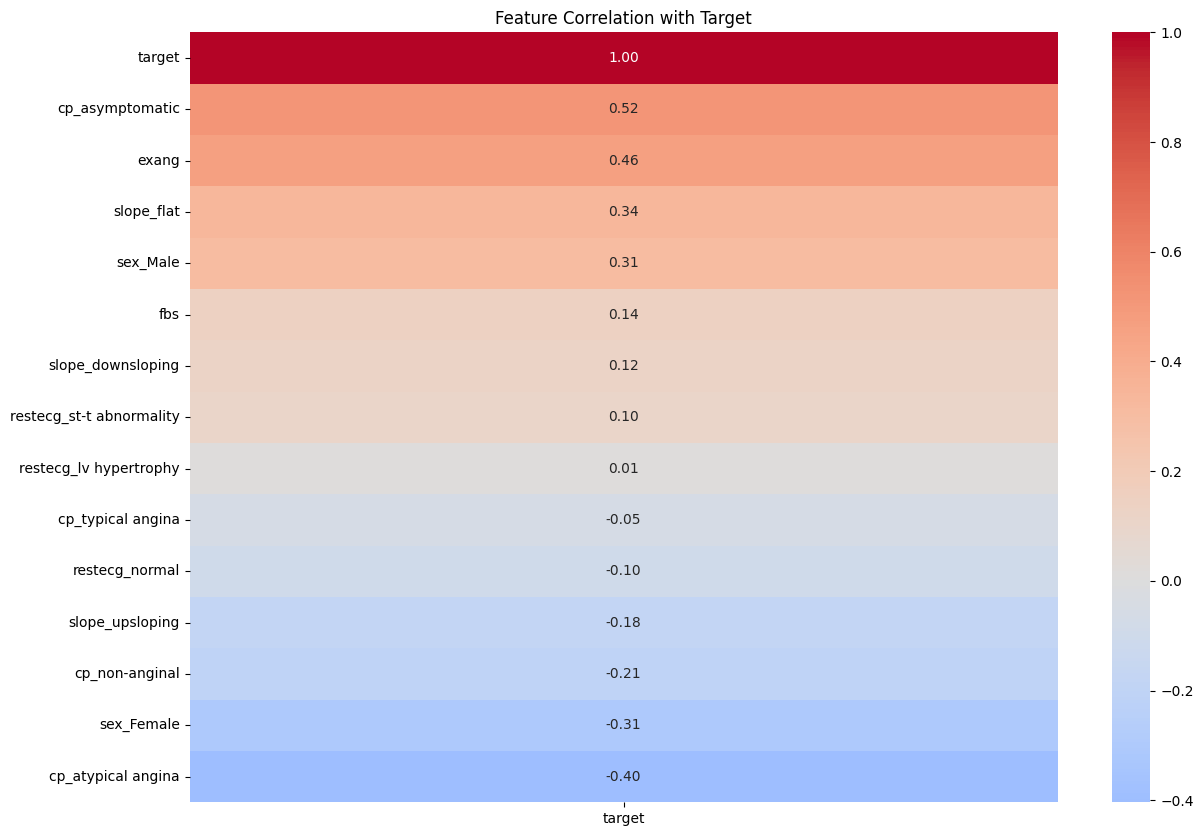

In [138]:
# encode categoricals temporarily to check correlation with target
temp = pd.get_dummies(df[['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'target']])
plt.figure(figsize=(14, 10))
sns.heatmap(temp.corr()[['target']].sort_values('target', ascending=False), 
            annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Feature Correlation with Target')
plt.show()

In [139]:
#drop restceg from analysis since it has very low correlation with target and many missing values
df = df.drop(columns=['restecg'])

In [140]:
df


,age,sex,cp,trestbps,chol,fbs,thalch,exang,oldpeak,slope,target
0,63,Male,typical angina,145.0,233.0,1.0,150.0,0.0,2.3,downsloping,0
1,67,Male,asymptomatic,160.0,286.0,0.0,108.0,1.0,1.5,flat,1
2,67,Male,asymptomatic,120.0,229.0,0.0,129.0,1.0,2.6,flat,1
3,37,Male,non-anginal,130.0,250.0,0.0,187.0,0.0,3.5,downsloping,0
4,41,Female,atypical angina,130.0,204.0,0.0,172.0,0.0,1.4,upsloping,0
...,...,...,...,...,...,...,...,...,...,...,...
915,54,Female,asymptomatic,127.0,333.0,1.0,154.0,0.0,0.0,NaN,1
916,62,Male,typical angina,NaN,139.0,0.0,NaN,NaN,NaN,NaN,0
917,55,Male,asymptomatic,122.0,223.0,1.0,100.0,0.0,0.0,NaN,1
918,58,Male,asymptomatic,NaN,385.0,1.0,NaN,NaN,NaN,NaN,0


In [141]:
num_cols = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak']
cat_cols = ['sex', 'cp', 'slope']
bin_cols = ['fbs', 'exang']  # already 0/1, just impute + scale

In [142]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

num_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

bin_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer([
    ('num', num_transformer, num_cols),
    ('cat', cat_transformer, cat_cols),
    ('bin', bin_transformer, bin_cols)
])

In [143]:
#data splitting
from sklearn.model_selection import train_test_split

X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape)
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

(736, 10) (184, 10)
target
1    0.552989
0    0.447011
Name: proportion, dtype: float64
target
1    0.554348
0    0.445652
Name: proportion, dtype: float64


              precision    recall  f1-score   support

  No Disease       0.81      0.72      0.76        82
     Disease       0.79      0.86      0.83       102

    accuracy                           0.80       184
   macro avg       0.80      0.79      0.79       184
weighted avg       0.80      0.80      0.80       184

ROC-AUC: 0.895


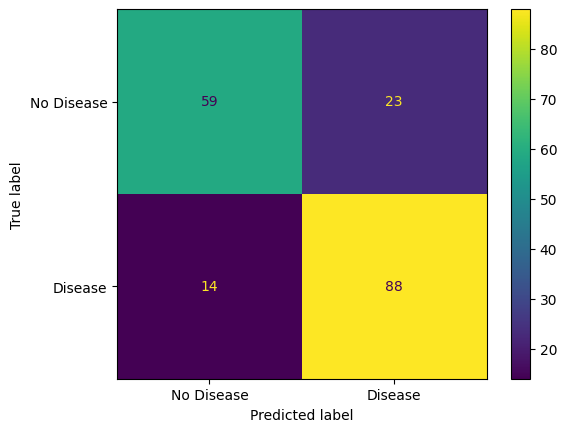

In [144]:

# Logistic regression is a good starting point for binary classification problems. It’s interpretable, fast to train, and often performs well with proper preprocessing. We’ll build a pipeline that includes our preprocessing steps followed by logistic regression, then evaluate its performance using classification metrics and a confusion matrix.

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, ConfusionMatrixDisplay

# Build full pipeline
lr_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(random_state=42, max_iter=1000))
])

# Fit
lr_pipe.fit(X_train, y_train)

# Predict
y_pred = lr_pipe.predict(X_test)
y_prob = lr_pipe.predict_proba(X_test)[:, 1]

# Evaluate
print(classification_report(y_test, y_pred, target_names=['No Disease', 'Disease']))
# print("ROC-AUC:", roc_auc_score(y_test, y_prob).round(4))
print("ROC-AUC:", round(roc_auc_score(y_test, y_prob), 4))
# Confusion matrix
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred), 
                       display_labels=['No Disease', 'Disease']).plot()
plt.show()


In [145]:
#Now let’s try a more complex model like Decision Tree to see if we can improve performance. Decision Trees can capture non-linear relationships and interactions between features, which might be beneficial for our dataset. We’ll use the same preprocessing pipeline and evaluate the Decision Tree’s performance using the same metrics.
from sklearn.tree import DecisionTreeClassifier

dt_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', DecisionTreeClassifier(random_state=42))
])

dt_pipe.fit(X_train, y_train)
y_pred_dt = dt_pipe.predict(X_test)
y_prob_dt = dt_pipe.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_dt, target_names=['No Disease', 'Disease']))
print("ROC-AUC:", round(roc_auc_score(y_test, y_prob_dt), 4))

# Train vs test accuracy to check overfitting
print("Train accuracy:", round(dt_pipe.score(X_train, y_train), 4))
print("Test accuracy:", round(dt_pipe.score(X_test, y_test), 4))

              precision    recall  f1-score   support

  No Disease       0.72      0.68      0.70        82
     Disease       0.75      0.78      0.77       102

    accuracy                           0.74       184
   macro avg       0.74      0.73      0.73       184
weighted avg       0.74      0.74      0.74       184

ROC-AUC: 0.7336
Train accuracy: 1.0
Test accuracy: 0.7391


In [146]:
#fix overfitting by tuning max_depth
for depth in [3, 5, 7]:
    dt = Pipeline([
        ('preprocessor', preprocessor),
        ('model', DecisionTreeClassifier(max_depth=depth, random_state=42))
    ])
    dt.fit(X_train, y_train)
    y_pred_d = dt.predict(X_test)
    y_prob_d = dt.predict_proba(X_test)[:, 1]
    print(f"Depth {depth} | Train: {round(dt.score(X_train, y_train), 3)} | Test: {round(dt.score(X_test, y_test), 3)} | AUC: {round(roc_auc_score(y_test, y_prob_d), 3)} | Disease Recall: {round(classification_report(y_test, y_pred_d, output_dict=True)['1']['recall'], 3)}")

Depth 3 | Train: 0.785 | Test: 0.755 | AUC: 0.857 | Disease Recall: 0.863
Depth 5 | Train: 0.84 | Test: 0.766 | AUC: 0.793 | Disease Recall: 0.833
Depth 7 | Train: 0.89 | Test: 0.75 | AUC: 0.779 | Disease Recall: 0.833


| Model | Accuracy | Disease Recall | AUC |
|---|---|---|---|
| Logistic Regression | **0.80** | 0.86 | **0.895** |
| DT depth=3 | 0.755 | **0.863** | 0.857 |
| DT default | 0.739 | 0.78 | 0.734 |




LR still wins overall — better accuracy and AUC. DT depth 3 barely edges recall but loses everywhere else.

In [147]:
for C in [0.01, 0.1, 1.0, 10, 100]:
    lr = Pipeline([
        ('preprocessor', preprocessor),
        ('model', LogisticRegression(C=C, random_state=42, max_iter=1000))
    ])
    lr.fit(X_train, y_train)
    y_pred_c = lr.predict(X_test)
    y_prob_c = lr.predict_proba(X_test)[:, 1]
    recall = classification_report(y_test, y_pred_c, output_dict=True)['1']['recall']
    print(f"C={C} | Train: {round(lr.score(X_train, y_train),3)} | Test: {round(lr.score(X_test, y_test),3)} | AUC: {round(roc_auc_score(y_test, y_prob_c),3)} | Disease Recall: {round(recall,3)}")
    #C=1.0 is your sweet spot. Beyond that (C=10, 100) nothing improves — model has already found optimal weights. Below that (C=0.01) regularization is too strong — recall drops to 0.814, underfitting.

C=0.01 | Train: 0.799 | Test: 0.772 | AUC: 0.88 | Disease Recall: 0.814
C=0.1 | Train: 0.8 | Test: 0.799 | AUC: 0.895 | Disease Recall: 0.853
C=1.0 | Train: 0.796 | Test: 0.799 | AUC: 0.895 | Disease Recall: 0.863
C=10 | Train: 0.798 | Test: 0.799 | AUC: 0.896 | Disease Recall: 0.863
C=100 | Train: 0.798 | Test: 0.799 | AUC: 0.896 | Disease Recall: 0.863


In [148]:
from sklearn.model_selection import cross_val_score

# LR cross-validation
lr_cv = cross_val_score(lr_pipe, X_train, y_train, cv=5, scoring='roc_auc')
print("LR CV AUC scores:", lr_cv.round(3))
print(f"LR CV Mean: {lr_cv.mean().round(3)} | Std: {lr_cv.std().round(3)}")

# DT depth=3 cross-validation
dt3_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', DecisionTreeClassifier(max_depth=3, random_state=42))
])
dt_cv = cross_val_score(dt3_pipe, X_train, y_train, cv=5, scoring='roc_auc')
print("\nDT depth=3 CV AUC scores:", dt_cv.round(3))
print(f"DT CV Mean: {dt_cv.mean().round(3)} | Std: {dt_cv.std().round(3)}")

LR CV AUC scores: [0.884 0.904 0.832 0.854 0.887]
LR CV Mean: 0.872 | Std: 0.026

DT depth=3 CV AUC scores: [0.792 0.829 0.789 0.793 0.79 ]
DT CV Mean: 0.799 | Std: 0.015



| Model              | Accuracy | Disease Recall | AUC   | CV Mean AUC | CV Std |
|--------------------|----------|----------------|-------|-------------|--------|
| LR (C=1.0)         | 0.800    | 0.863          | 0.895 | 0.872       | 0.026  |
| LR (C=0.01)        | 0.772    | 0.814          | 0.880 | —           | —      |
| DT default         | 0.739    | 0.780          | 0.734 | —           | —      |
| DT depth=3         | 0.755    | 0.863          | 0.857 | 0.799       | 0.015  |


In [149]:
# Best model — LR C=1.0
best_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(C=1.0, random_state=42, max_iter=1000))
])

best_model.fit(X_train, y_train)

# Predictions
y_pred_final = best_model.predict(X_test)
y_prob_final = best_model.predict_proba(X_test)[:, 1]

# Show sample predictions
results = X_test.copy()
results['Actual'] = y_test.values
results['Predicted'] = y_pred_final
results['Disease Probability'] = y_prob_final.round(3)

print(results[['Actual', 'Predicted', 'Disease Probability']].head(15))

     Actual  Predicted  Disease Probability
514       1          0                0.457
825       1          1                0.971
854       1          1                0.935
804       1          1                0.970
887       0          1                0.625
483       0          1                0.851
273       0          1                0.622
540       1          1                0.931
402       0          0                0.195
601       1          0                0.271
278       1          0                0.109
289       0          0                0.087
241       0          0                0.019
88        0          0                0.162
717       0          1                0.806


In [150]:
from sklearn.svm import SVC

svc_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', SVC(kernel='rbf', probability=True, random_state=42))
])

svc_pipe.fit(X_train, y_train)
y_pred_svc = svc_pipe.predict(X_test)
y_prob_svc = svc_pipe.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_svc, target_names=['No Disease', 'Disease']))
print("ROC-AUC:", round(roc_auc_score(y_test, y_prob_svc), 4))
print("Train accuracy:", round(svc_pipe.score(X_train, y_train), 4))
print("Test accuracy:", round(svc_pipe.score(X_test, y_test), 4))

              precision    recall  f1-score   support

  No Disease       0.86      0.68      0.76        82
     Disease       0.78      0.91      0.84       102

    accuracy                           0.81       184
   macro avg       0.82      0.80      0.80       184
weighted avg       0.82      0.81      0.81       184

ROC-AUC: 0.8847
Train accuracy: 0.856
Test accuracy: 0.8098


In [151]:
# Best model — SVC rbf (highest recall + accuracy)
best_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', SVC(kernel='rbf', probability=True, random_state=42))
])

best_model.fit(X_train, y_train)
y_pred_final = best_model.predict(X_test)
y_prob_final = best_model.predict_proba(X_test)[:, 1]

results = X_test.copy()
results['Actual'] = y_test.values
results['Predicted'] = y_pred_final
results['Disease Probability'] = y_prob_final.round(3)
print(results[['Actual', 'Predicted', 'Disease Probability']].head(15))

     Actual  Predicted  Disease Probability
514       1          1                0.492
825       1          1                0.876
854       1          1                0.846
804       1          1                0.901
887       0          1                0.688
483       0          1                0.887
273       0          0                0.394
540       1          1                0.903
402       0          0                0.070
601       1          0                0.442
278       1          0                0.051
289       0          0                0.131
241       0          0                0.025
88        0          0                0.101
717       0          1                0.910


In [152]:
# SVC cross-validation
svc_cv = cross_val_score(svc_pipe, X_train, y_train, cv=5, scoring='roc_auc')
print("SVC CV AUC scores:", svc_cv.round(3))
print(f"SVC CV Mean: {svc_cv.mean().round(3)} | Std: {svc_cv.std().round(3)}")

SVC CV AUC scores: [0.877 0.911 0.819 0.857 0.876]
SVC CV Mean: 0.868 | Std: 0.03


## Final Model Comparison

| Model | Accuracy | Disease Recall | AUC | CV Mean AUC | CV Std |
|---|---|---|---|---|---|
| **SVC (rbf)** | **0.810** | **0.910** | 0.8847 | — | — |
| LR (C=1.0) | 0.800 | 0.863 | **0.895** | 0.872 | 0.026 |
| DT depth=3 | 0.755 | 0.863 | 0.857 | 0.799 | 0.015 |
| LR (C=0.01) | 0.772 | 0.814 | 0.880 | — | — |
| DT default | 0.739 | 0.780 | 0.734 | — | — |
| **SVC (rbf)** | **0.810** | **0.910** | 0.8847 | — | — |

**Winner: SVC (rbf)**
- Best Disease Recall (0.91) — catches 93/102 sick patients vs LR's 88/102
- Best Accuracy (0.81)
- LR has marginally better AUC (0.895 vs 0.8847) but recall gap is clinically more important
- DT overfits badly without depth limit — train 1.0 vs test 0.739

## Key Observations

1. **SVC with rbf kernel is the final model** — Disease Recall 0.91 is the highest across all models.
   In clinical context, missing a sick patient (FN) is far more costly than a false alarm (FP).

2. **LR is the most stable model** — near-zero train-test gap, CV std of 0.026, AUC 0.895.
   If interpretability or deployment speed matters, LR is the practical choice.

3. **Decision Tree without depth limit = textbook overfitting** — train 1.0 vs test 0.739.
   max_depth=3 fixed it but still couldn't beat LR or SVC.

4. **Ng connection** — LR finds a linear decision boundary via sigmoid + log loss.
   SVC finds a non-linear boundary via rbf kernel + margin maximization.
   Same goal, different optimization — SVM won because this data isn't linearly separable.